In [1]:
import os, cygnet, torch
from matplotlib import pyplot as plt
import imageio.v3 as iio
import numpy as np
import torchvision.transforms.v2 as transforms

net_folder = "/home/frx/cygnet/saved_models"
for el in os.listdir(net_folder):
	print(el)

metric_test_path = "/home/frx/dataset/image_dataset/metric_test"
raw_path = os.path.join(metric_test_path, "raw_images")
rp_path = os.path.join(metric_test_path, "redpixs")

def load_pic_pair(idx):
	raw_image_path = os.path.join(raw_path, f"raw_{idx}.png")
	raw = iio.imread(raw_image_path)
	redpix_image_path = os.path.join(rp_path, f"rp_{idx}.png")
	redpix = iio.imread(redpix_image_path)

	return raw, redpix

in_t = cygnet.input_transform_builder(4)
upscaler_t = transforms.Resize((2304, 4096), "nearest-exact", antialias = False)

def get_prediction(net, input, tresh = 0.2):
	device = "cuda"

	net.eval()
	with torch.inference_mode():
		pred = net(input.unsqueeze(0).to(device))
	spred = torch.sigmoid(pred)
	sspred = (spred > tresh).float()

	return sspred

def compute_energy(img):
	return img.sum()

best_model_base16_res_drop.pt
2026_Jul_23__16:17_best_model_base16_res_drop.pt
best_model_base8_res_drop_goodtest.pt
best_model_base16_drop.pt
bestest_on_real.pt
best_model_base8.pt
best_model.pt
best_model_base16_res.pt


In [2]:
"""
missed some energy in picture 505: 55
missed 0.07923930269413629% of the energy

missed some energy in picture 512: 156
missed 0.19846065771897464% of the energy

missed some energy in picture 515: 1
missed 0.0005771006463527238% of the energy

missed some energy in picture 516: 4
missed 0.006977393245883338% of the energy

missed some energy in picture 541: 391
missed 3.7015999242639404% of the energy

missed some energy in picture 546: 28
missed 0.009769952511052258% of the energy

missed some energy in picture 551: 3
missed 0.013559934912312421% of the energy

missed some energy in picture 560: 24
missed 0.019138145513699724% of the energy

missed some energy in picture 562: 619
missed 1.2714649576863035% of the energy

missed some energy in picture 616: 294
missed 100.0% of the energy
"""

picnum = 617

raw, redpix = load_pic_pair(picnum)

# cygnet.quickplot(raw, "raw")
# cygnet.quickplot(redpix, "redpix", None, None)

raw_in = cygnet.itrtr(in_t(raw))
redpix_gt = cygnet.itrtr(in_t(redpix))

0.0
1.0


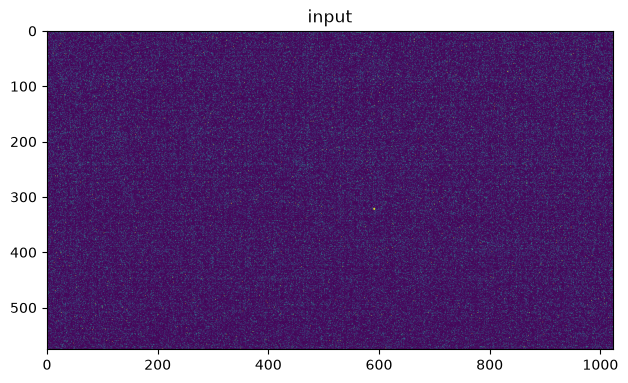

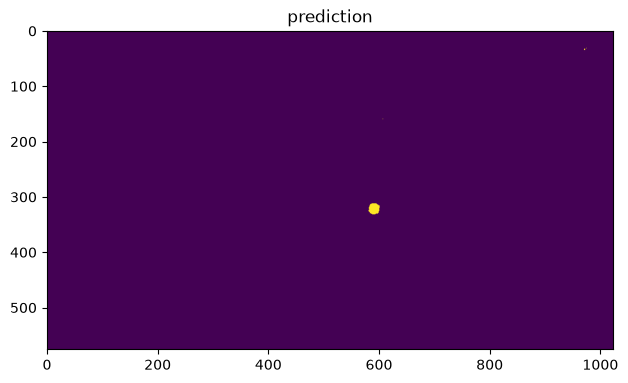

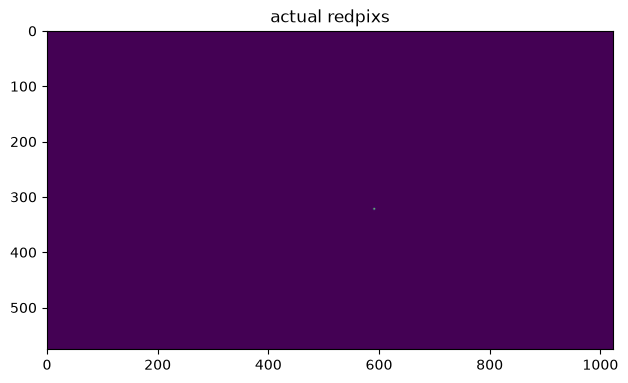

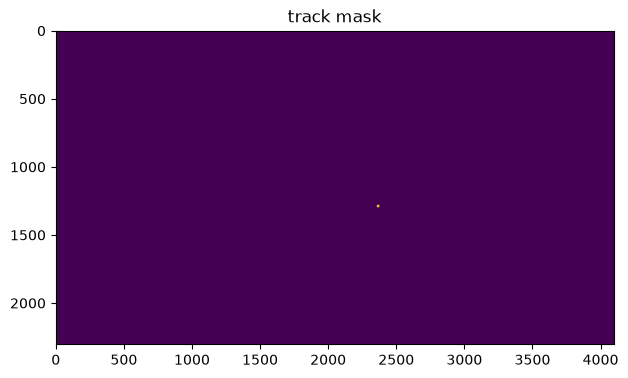

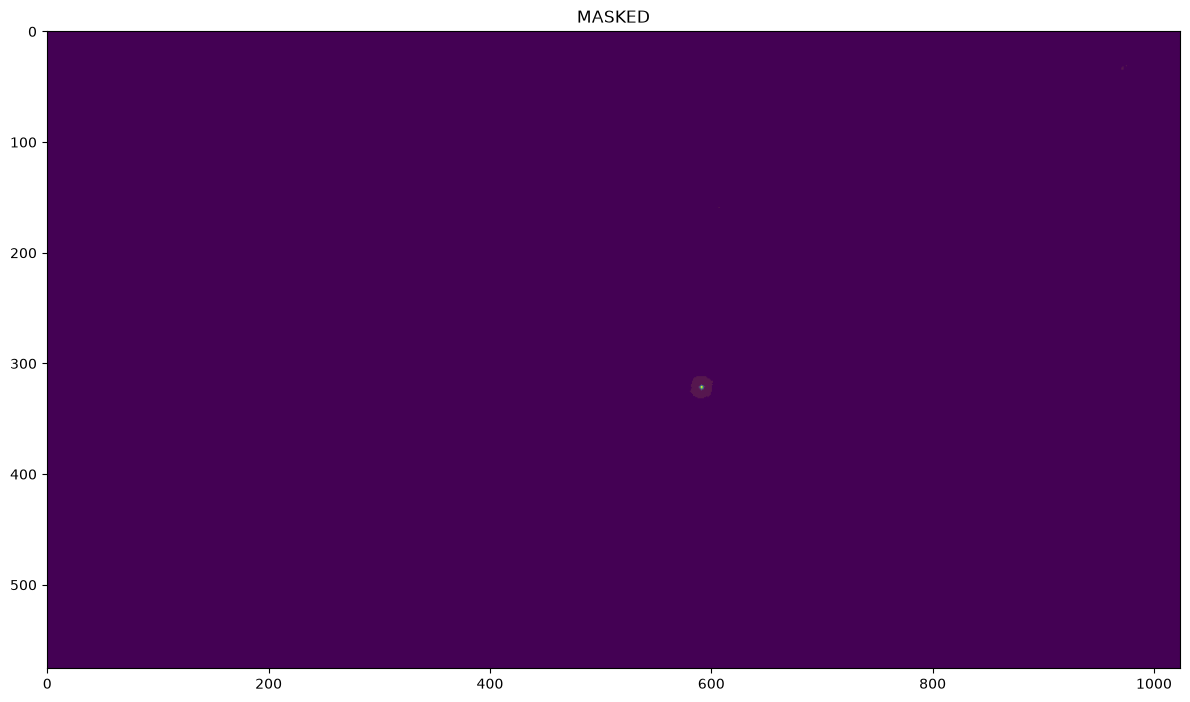

1162
1162


In [3]:
net_file = "2026_Jul_23__16:17_best_model_base16_res_drop.pt"

net_path = os.path.join(net_folder, net_file)
device = "cuda"

net = cygnet.SkipNet(16).to(device)
net.load_state_dict(torch.load(net_path, weights_only=False)['model_state_dict'])
net.eval()

ttt = 0.15
sspred = get_prediction(net, raw_in, ttt).cpu()

print(sspred.min().item())
print(sspred.max().item())

rmin = 0.00305
rmax = 0.0031

mask = (redpix > 0)

cygnet.quickplot(raw_in.squeeze(), "input", rmax, rmin)
cygnet.quickplot(sspred.cpu().squeeze(), "prediction", None, None)
cygnet.quickplot(redpix_gt.squeeze(), "actual redpixs", None, None)
cygnet.quickplot(mask.squeeze(), "track mask", None, None)

cygnet.debug_plot(redpix_gt.squeeze(), sspred.cpu().squeeze(), 0.1, vmin=None, vmax=None)

u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
masked = np.where(u_pred, redpix.squeeze(), 0)
print(compute_energy(redpix))
print(compute_energy(masked))

# cygnet.quickplot(masked.squeeze(), "masked values", None, None)

In [4]:
# loop su tutte

num = len(os.listdir(raw_path))
recompute = False

if recompute:
	for idx in range(num):
		raw, redpix = load_pic_pair(idx)
		raw_in = cygnet.itrtr(in_t(raw))
		redpix_gt = cygnet.itrtr(in_t(redpix))
		sspred = get_prediction(net, raw_in, ttt).cpu()
		mask = (redpix > 0)
		u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
		masked = np.where(u_pred, redpix.squeeze(), 0)

		en_tot = compute_energy(redpix)
		en_seen = compute_energy(masked)

		en_missed = en_tot - en_seen
		if en_missed > 0:
			print(f"missed some energy in picture {idx}: {en_missed} out of {en_tot} counts" )
			print(f"missed {en_missed/en_tot * 100}% of the energy")
			print()

"""
missed some energy in picture 505: 55
missed 0.07923930269413629% of the energy

missed some energy in picture 512: 156
missed 0.19846065771897464% of the energy

missed some energy in picture 515: 1
missed 0.0005771006463527238% of the energy

missed some energy in picture 516: 4
missed 0.006977393245883338% of the energy

missed some energy in picture 541: 391
missed 3.7015999242639404% of the energy

missed some energy in picture 546: 28
missed 0.009769952511052258% of the energy

missed some energy in picture 551: 3
missed 0.013559934912312421% of the energy

missed some energy in picture 560: 24
missed 0.019138145513699724% of the energy

missed some energy in picture 562: 619
missed 1.2714649576863035% of the energy

missed some energy in picture 616: 294
missed 100.0% of the energy
"""

'\nmissed some energy in picture 505: 55\nmissed 0.07923930269413629% of the energy\n\nmissed some energy in picture 512: 156\nmissed 0.19846065771897464% of the energy\n\nmissed some energy in picture 515: 1\nmissed 0.0005771006463527238% of the energy\n\nmissed some energy in picture 516: 4\nmissed 0.006977393245883338% of the energy\n\nmissed some energy in picture 541: 391\nmissed 3.7015999242639404% of the energy\n\nmissed some energy in picture 546: 28\nmissed 0.009769952511052258% of the energy\n\nmissed some energy in picture 551: 3\nmissed 0.013559934912312421% of the energy\n\nmissed some energy in picture 560: 24\nmissed 0.019138145513699724% of the energy\n\nmissed some energy in picture 562: 619\nmissed 1.2714649576863035% of the energy\n\nmissed some energy in picture 616: 294\nmissed 100.0% of the energy\n'

In [5]:
# ottimizzazione soglia

t_list = [0.0125, 0.025, 0.0375, 0.05, 0.065, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
recompute = False

if recompute:
	avg_miss_list = []
	worst_miss_list = []
	best_miss_list = []

	avg_compression_list = []
	worst_compression_list = []
	best_compression_list = []

	missed_tracks_list = []

	for val in t_list:
		print(val)
		en_missed_percent_list = []
		compression_list = []

		missed = 0

		for idx in range(num):
			raw, redpix = load_pic_pair(idx)
			raw_in = cygnet.itrtr(in_t(raw))
			redpix_gt = cygnet.itrtr(in_t(redpix))
			sspred = get_prediction(net, raw_in, val).cpu()
			mask = (redpix > 0)
			u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
			masked = np.where(u_pred, redpix.squeeze(), 0)

			en_tot = compute_energy(redpix)
			en_seen = compute_energy(masked)

			en_missed = en_tot - en_seen
			en_missed_percent = en_missed/(en_tot + 1e-8) * 100
			compression = sspred.float().mean().item() * 100

			en_missed_percent_list.append(en_missed_percent)
			compression_list.append(compression)

			if en_missed == en_tot and en_tot > 0:
				print(f"missed a track with energy = {en_tot}")
				missed += 1

		avg_miss = np.array(en_missed_percent_list).mean().item()
		max_miss = np.array(en_missed_percent_list).max().item()
		min_miss = np.array(en_missed_percent_list).min().item()

		avg_miss_list.append(avg_miss)
		worst_miss_list.append(max_miss)
		best_miss_list.append(min_miss)

		avg_comp = np.array(compression_list).mean().item()
		max_comp = np.array(compression_list).max().item()
		min_comp = np.array(compression_list).min().item()

		avg_compression_list.append(avg_comp)
		worst_compression_list.append(max_comp)
		best_compression_list.append(min_comp)

		missed_tracks_list.append(missed)

for i in range(len(t_list)):
	print(f"=== t={t_list[i]}: ===")
	print(f"completely missed tracks: {missed_tracks_list[i]}")
	print(f"miss rate           = {avg_miss_list[i]:6.2f}%; compression rate       = {avg_compression_list[i]:6.2f}%")
	print(f"lowest energy miss  = {best_miss_list[i]:6.2f}%; lowest retention rate  = {best_compression_list[i]:6.2f}%")
	print(f"highest energy miss = {worst_miss_list[i]:6.2f}%; highest retention rate = {worst_compression_list[i]:6.2f}%")
	print()

skip = 2
drop = len(t_list)

plt.figure(figsize=(12,12))
plt.plot(t_list[skip:drop], avg_miss_list[skip:drop], color='red', marker='P', label='avg energy missed %')
plt.plot(t_list[skip:drop], avg_compression_list[skip:drop], color='blue', marker='P', label='avg pixel retention %')
plt.xlabel('p values')
plt.ylabel('%')
plt.ylim((0., 0.8))
plt.xlim((0., 0.35))
plt.grid()
plt.legend()
plt.title("averages")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,12))
plt.plot(t_list[skip:drop], best_miss_list[skip:drop], color='red', marker='P', label='best energy missed %')
plt.plot(t_list[skip:drop], best_compression_list[skip:drop], color='blue', marker='P', label='best pixel retention %')
plt.xlabel('p values')
plt.ylabel('%')
plt.ylim((-0.01, 0.12))
plt.xlim((0., 0.35))
plt.grid()
plt.legend()
plt.title("best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,12))
plt.plot(t_list[skip:drop], worst_miss_list[skip:drop], color='red', marker='P', label='worst energy missed %')
plt.plot(t_list[skip:drop], worst_compression_list[skip:drop], color='blue', marker='P', label='worst pixel retention %')
plt.xlabel('p values')
plt.ylabel('%')
plt.ylim((0., 110))
plt.xlim((0., 0.35))
plt.grid()
plt.legend()
plt.title("worst")
plt.tight_layout()
plt.show()

=== t=0.0125: ===


NameError: name 'missed_tracks_list' is not defined

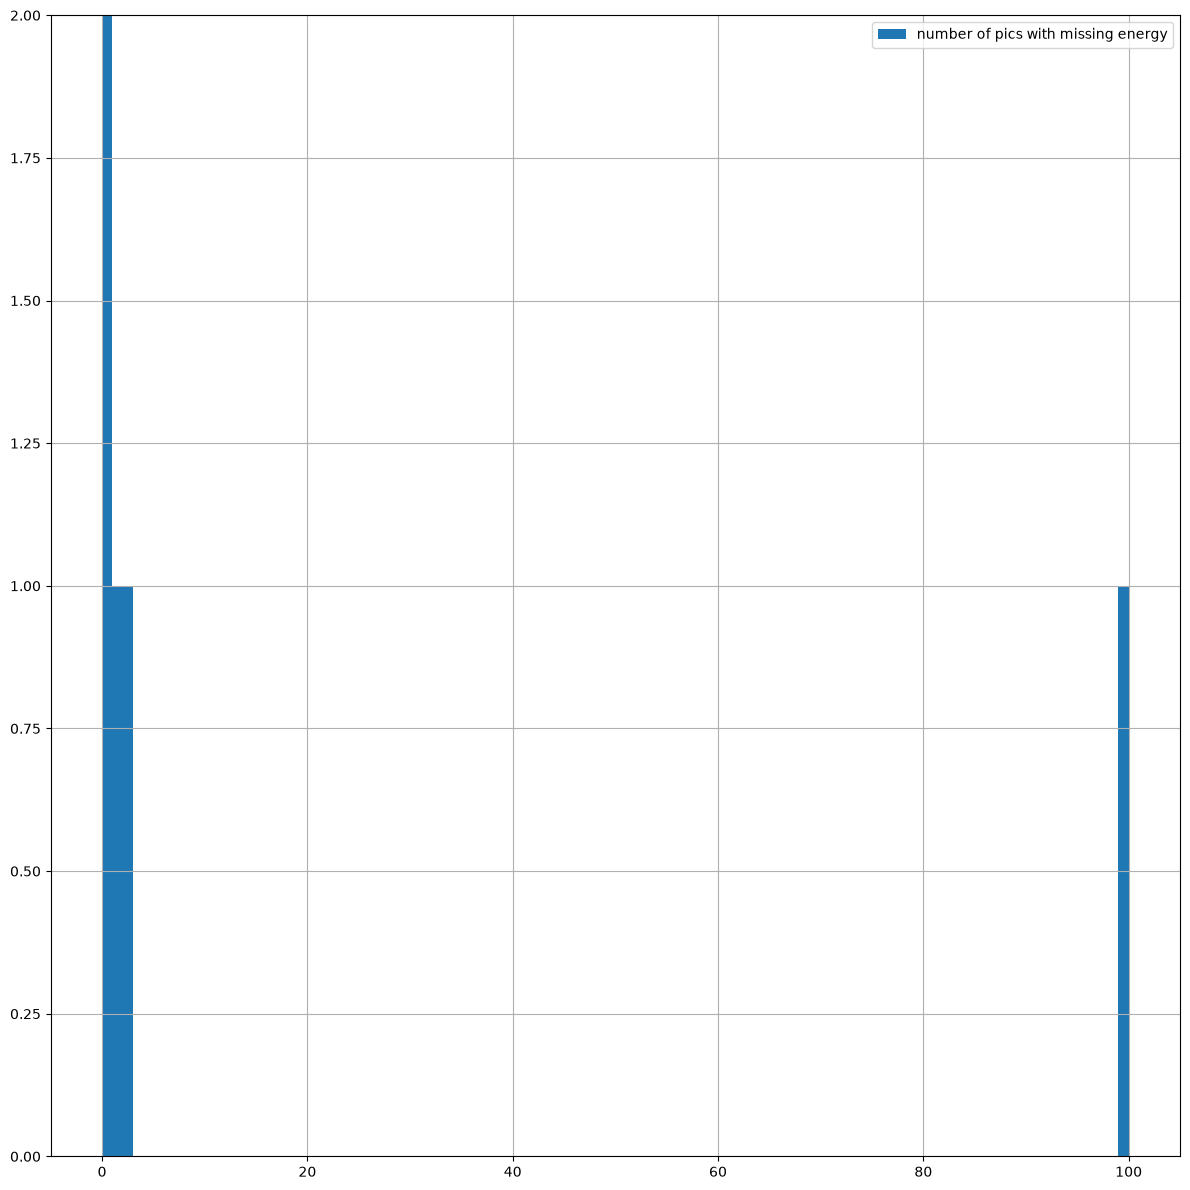

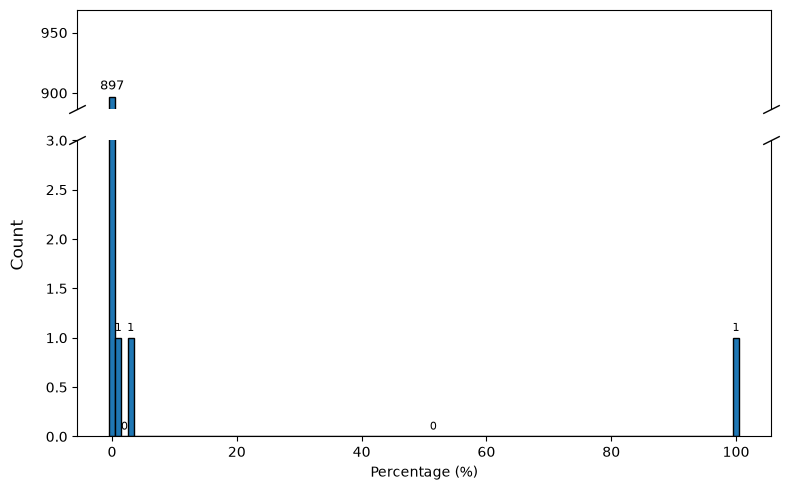

In [8]:
recompute = False
val = 0.15

if recompute:
	print(val)
	en_missed_percent_list = []
	compression_list = []

	missed = 0

	for idx in range(num):
		raw, redpix = load_pic_pair(idx)
		raw_in = cygnet.itrtr(in_t(raw))
		redpix_gt = cygnet.itrtr(in_t(redpix))
		sspred = get_prediction(net, raw_in, val).cpu()
		mask = (redpix > 0)
		u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
		masked = np.where(u_pred, redpix.squeeze(), 0)

		en_tot = compute_energy(redpix)
		en_seen = compute_energy(masked)

		en_missed = en_tot - en_seen
		en_missed_percent = en_missed/(en_tot + 1e-8) * 100
		compression = sspred.float().mean().item() * 100

		en_missed_percent_list.append(en_missed_percent)
		compression_list.append(compression)

		if en_missed == en_tot and en_tot > 0:
			print(f"missed a track with energy = {en_tot}")
			missed += 1

	avg_miss = np.array(en_missed_percent_list).mean().item()
	max_miss = np.array(en_missed_percent_list).max().item()
	min_miss = np.array(en_missed_percent_list).min().item()

	avg_comp = np.array(compression_list).mean().item()
	max_comp = np.array(compression_list).max().item()
	min_comp = np.array(compression_list).min().item()

plt.figure(figsize=(12,12))
plt.hist(en_missed_percent_list, 100, label="number of pics with missing energy")
plt.xlabel('')
plt.ylabel('')
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

data = np.array(en_missed_percent_list)

# --- 1. build fixed-width bin edges ---
bin_width = 1.0
lo = np.floor(data.min()) - 0.5
hi = np.ceil(data.max()) + 0.5
fixed_edges = np.arange(lo, hi + bin_width, bin_width)

# figure out which bins are empty, using a throwaway count pass
raw_counts, _ = np.histogram(data, bins=fixed_edges)

# --- 2. merge consecutive empty bins into single wide bins ---
merged_edges = [fixed_edges[0]]
i, n = 0, len(raw_counts)
while i < n:
    if raw_counts[i] == 0:
        j = i
        while j < n and raw_counts[j] == 0:
            j += 1
        merged_edges.append(fixed_edges[j])
        i = j
    else:
        merged_edges.append(fixed_edges[i + 1])
        i += 1
merged_edges = np.array(merged_edges)

# --- 3. plot with ax.hist directly, using the merged (variable-width) edges ---
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 5),
    gridspec_kw={'height_ratios': [1, 3]}
)

counts, edges, _ = ax_top.hist(data, bins=merged_edges, edgecolor='black')
ax_bottom.hist(data, bins=merged_edges, edgecolor='black')

peak = counts.max()
nonpeak = counts[counts != peak]
second = nonpeak.max() if len(nonpeak) else 0

top_ylim = (peak - max(10, second * 2), peak + max(20, peak * 0.08))
bottom_ylim = (0, second + max(2, second * 0.3))
ax_top.set_ylim(*top_ylim)
ax_bottom.set_ylim(*bottom_ylim)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
ax_bottom.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kwargs)
ax_bottom.plot([0, 1], [1, 1], transform=ax_bottom.transAxes, **kwargs)

# --- 4. annotate bars ---
centers = (edges[:-1] + edges[1:]) / 2
for xc, val in zip(centers, counts):
    if bottom_ylim[0] <= val <= bottom_ylim[1]:
        ax_bottom.annotate(f"{int(val)}", xy=(xc, val), xytext=(0, 3),
                            textcoords='offset points', ha='center', va='bottom', fontsize=8)
    if top_ylim[0] <= val <= top_ylim[1]:
        ax_top.annotate(f"{int(val)}", xy=(xc, val), xytext=(0, 3),
                         textcoords='offset points', ha='center', va='bottom', fontsize=9)

ax_bottom.set_xlabel("Percentage (%)")
fig.supylabel("Count")
plt.tight_layout()
plt.show()